# 09. Квантовая нейросеть (TensorFlow Quantum)

## Схема: PQC + плотные слои

1. **Кодирование:** каждую компоненту PC после `clip` в $[-1,1]$ вращают вокруг $X$ (RX) на кубитах.  
2. **Параметризованная схема:** RY, CNOT, RY; на выходе — **ожидания** операторов $Z$ на каждом кубите (4 числа).  
3. **Классика поверх кванта:** два слоя `Dense` с `relu` и `Dense(4) + softmax`. Итог — 4-вершинная классификация, совместимая с `y_train` из сплитов.

In [1]:
from pathlib import Path
import sys
import os

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "src" / "helpers.py").is_file():
        sys.path.insert(0, str((_p / "src").resolve()))
        os.chdir(_p)
        break

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
from helpers import init_notebook_path, ensure_dirs, PROJECT_ROOT, PLOT_DIR, DATA_DIR, RANDOM_STATE
ROOT = init_notebook_path()
ensure_dirs()
print("PROJECT_ROOT", PROJECT_ROOT)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq
import sympy
from helpers import load_xy_from_processed, classification_metrics_dict, print_report, append_metrics_store, PLOT_DIR, CLASS_NAMES, RANDOM_STATE

2026-04-25 01:16:47.907078: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-25 01:16:47.907117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-25 01:16:47.908121: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
tf.keras.utils.set_random_seed(RANDOM_STATE)
X_train, X_val, X_test, y_train, y_val, y_test, _ = load_xy_from_processed()
n_qubits = 8
pca = PCA(n_components=n_qubits, random_state=RANDOM_STATE)
Xt = pca.fit_transform(X_train)
Xv = pca.transform(X_val)
Xte = pca.transform(X_test)
qubits = cirq.GridQubit.rect(1, n_qubits)

In [5]:
def encode_row(row):
    c = cirq.Circuit()
    for i in range(n_qubits):
        c += cirq.rx(float(np.clip(row[i], -1, 1)) * np.pi)(qubits[i])
    return c

def to_tensor(mat):
    return tfq.convert_to_tensor([encode_row(mat[i]) for i in range(len(mat))])

In [6]:
import sympy
import cirq

n_layers = 3  


theta = sympy.symbols(f't0:{2 * n_qubits * n_layers}')
mod = cirq.Circuit()

p = 0
for layer in range(n_layers):

    for q in qubits:
        mod += cirq.ry(theta[p])(q)
        p += 1

    for i in range(n_qubits):
        mod += cirq.CNOT(
            qubits[i],
            qubits[(i + 1) % n_qubits]
        )

    for q in qubits:
        mod += cirq.ry(theta[p])(q)
        p += 1

readout = [
    cirq.Z(qubits[0]),
    cirq.Z(qubits[1]),
    cirq.Z(qubits[2]),
    cirq.Z(qubits[3]),
    cirq.Z(qubits[0]) * cirq.Z(qubits[1]),
    cirq.Z(qubits[1]) * cirq.Z(qubits[2]),
]

In [7]:
train_t = to_tensor(Xt)
val_t = to_tensor(Xv)
test_t = to_tensor(Xte)
inp = tf.keras.Input(shape=(), dtype=tf.string)
exp = tfq.layers.PQC(mod, readout)(inp)
x = tf.keras.layers.Dense(32, activation='relu')(exp)
x = tf.keras.layers.Dense(16, activation='relu')(x)
out = tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')(x)
model = tf.keras.Model(inp, out)

In [8]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None,)]                 0         
                                                                 
 pqc (PQC)                   (None, 6)                 48        
                                                                 
 dense (Dense)               (None, 32)                224       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 4)                 68        
                                                                 
Total params: 868 (3.39 KB)
Trainable params: 868 (3.39 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
sub = len(y_train)

cb = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss')
]

h = model.fit(train_t[:sub], y_train[:sub], validation_data=(val_t, y_val), epochs=120, batch_size=32, callbacks=cb, verbose=1)

Epoch 1/120
175/175 [==============================] - 7s 34ms/step - loss: 1.3632 - accuracy: 0.3346 - val_loss: 1.2974 - val_accuracy: 0.4225
Epoch 2/120
175/175 [==============================] - 6s 34ms/step - loss: 1.2232 - accuracy: 0.4186 - val_loss: 1.1572 - val_accuracy: 0.4342
Epoch 3/120
175/175 [==============================] - 6s 34ms/step - loss: 1.1186 - accuracy: 0.4552 - val_loss: 1.1037 - val_accuracy: 0.4583
Epoch 4/120
175/175 [==============================] - 6s 34ms/step - loss: 1.0727 - accuracy: 0.4688 - val_loss: 1.0783 - val_accuracy: 0.4708
Epoch 5/120
175/175 [==============================] - 6s 34ms/step - loss: 1.0431 - accuracy: 0.4843 - val_loss: 1.0575 - val_accuracy: 0.4642
Epoch 6/120
175/175 [==============================] - 6s 34ms/step - loss: 1.0173 - accuracy: 0.4988 - val_loss: 1.0400 - val_accuracy: 0.4842
Epoch 7/120
175/175 [==============================] - 6s 34ms/step - loss: 0.9954 - accuracy: 0.5113 - val_loss: 1.0200 - val_accuracy:

## Почему метрики часто невысокие

- **Мало** обучающих точек в коде (`sub` из скорости симуляции) и **немного** эпох.  
- **Клип** входа в $[-1,1]$ усекает сильно отличающиеся по масштабу PC — часть сигнала **насыщается** по краям.  
- PQC+небольшой классификатор — **учебный** контраст к MLP, а не максимальное качество.

In [10]:
y_pred = model.predict(test_t, verbose=0).argmax(axis=1)
m = classification_metrics_dict(y_test, y_pred)
print(m)
print_report(y_test, y_pred)

{'accuracy': 0.615, 'precision_macro': 0.6247915332087863, 'recall_macro': 0.615, 'f1_macro': 0.6153196655393616, 'precision_micro': 0.615, 'recall_micro': 0.615, 'f1_micro': 0.615}
              precision    recall  f1-score   support

    OPEN_SEA       0.77      0.88      0.82       300
 COASTAL_SEA       0.47      0.47      0.47       300
  NEAR_COAST       0.45      0.49      0.47       300
   COASTLINE       0.81      0.62      0.70       300

    accuracy                           0.61      1200
   macro avg       0.62      0.61      0.62      1200
weighted avg       0.62      0.61      0.62      1200



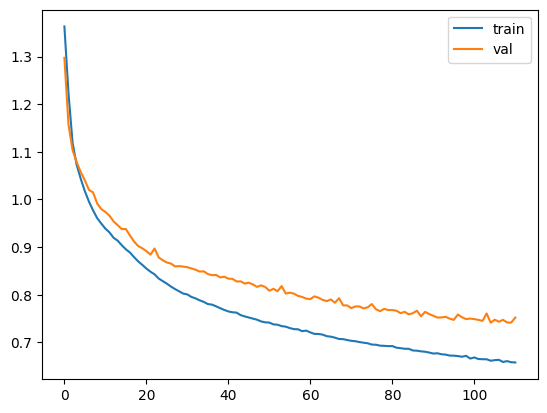

In [11]:
append_metrics_store('tfq_pqc', m)
plt.figure()
plt.plot(h.history['loss'], label='train')
plt.plot(h.history['val_loss'], label='val')
plt.legend()
plt.savefig(PLOT_DIR / 'tfq_loss.png', dpi=150)
plt.show()
plt.close()

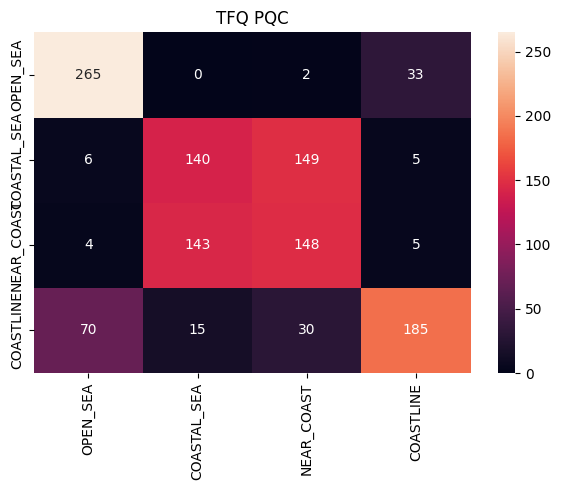

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(CLASS_NAMES)))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('TFQ PQC')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_tfq.png', dpi=150)
plt.show()
plt.close()
